Load cleaned baseline data from pickle file and check for good transfer

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_pickle('../data/cleaned_games.pkl')

with open('../data/genre_columns.pkl', 'rb') as f:
    genre_features = pickle.load(f)

Now build out baseline linear regreassion model, starting with grabbing the needed features:

In [2]:
features = [
    'price',
    'year',
    'num_tags',
    'has_tags',
    'dev_success',
    'dev_had_success',
    'log_dev_experience',
    'num_devs',
    'is_free'
] + list(genre_features)


Then the data splitting. Training and Testing data is not random, rather they are split by time, as the purpose of this model is time-based:

In [3]:
X = df[features]
y = df['hit']

split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

Now the baseline model:

In [4]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Users/jcook/Video-Game-Sales-Analysis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8183332846160591
F1 Score: 0.22670150553689186
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     33069
           1       0.13      0.80      0.23      1142

    accuracy                           0.82     34211
   macro avg       0.56      0.81      0.56     34211
weighted avg       0.96      0.82      0.87     34211



In [6]:
coeffs = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

coeffs = coeffs.sort_values(by='coefficient', ascending=False)

print(coeffs.head(15))

                  feature  coefficient
3                has_tags     4.488033
4             dev_success     2.506423
21           Free To Play     0.994669
25  Massively Multiplayer     0.470047
5         dev_had_success     0.350154
38              Utilities     0.301478
29                    RPG     0.251230
8                 is_free     0.223540
36               Strategy     0.181976
41         Web Publishing     0.147374
33             Simulation     0.102458
2                num_tags     0.090868
30                 Racing     0.088787
7                num_devs     0.076881
39       Video Production     0.060533


In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

,Predicted: Miss,Predicted: Hit
Actual: Miss,27085,5984
Actual: Hit,231,911


This first Model showed some apparent issues, but I will keep it to show the development of the model and my changes. The first is to include scaling and allow for more iterations. I also will be removing the has_tags feature, as I beleive it should not have weight so far beyond something like dev_success. 

In [8]:
round_2_features = [
    'price',
    'year',
    'num_tags',
    'dev_success',
    'dev_had_success',
    'log_dev_experience',
    'num_devs',
    'is_free'
] + list(genre_features)

In [9]:
X_2 = df[round_2_features]
y_2 = df['hit']

split_index = int(len(df) * 0.7)

X_2_train = X_2.iloc[:split_index]
X_2_test = X_2.iloc[split_index:]

y_2_train = y_2.iloc[:split_index]
y_2_test = y_2.iloc[split_index:]

In [10]:
scaler = StandardScaler()

X_2_train_scaled = scaler.fit_transform(X_2_train)
X_2_test_scaled = scaler.transform(X_2_test)

model_2 = LogisticRegression(max_iter=3000, class_weight='balanced')
model_2.fit(X_2_train_scaled, y_2_train)

y_2_pred = model_2.predict(X_2_test_scaled)

In [11]:
print("Accuracy (Round 2):", accuracy_score(y_2_test, y_2_pred))
print("F1 Score (Round 2):", f1_score(y_2_test, y_2_pred))
print(classification_report(y_2_test, y_2_pred))

Accuracy (Round 2): 0.9584344216772384
F1 Score (Round 2): 0.3008849557522124
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     33069
           1       0.34      0.27      0.30      1142

    accuracy                           0.96     34211
   macro avg       0.66      0.63      0.64     34211
weighted avg       0.95      0.96      0.96     34211



In [12]:
coeffs_2 = pd.DataFrame({
    'feature': round_2_features,
    'coefficient': model_2.coef_[0]
})

coeffs_2 = coeffs_2.sort_values(by='coefficient', ascending=False)

print(coeffs_2.head(15))

                  feature  coefficient
2                num_tags     1.349256
3             dev_success     0.558088
20           Free To Play     0.244340
7                 is_free     0.127420
28                    RPG     0.119203
37              Utilities     0.101710
4         dev_had_success     0.052141
32             Simulation     0.049995
35               Strategy     0.047813
24  Massively Multiplayer     0.041637
6                num_devs     0.034792
40         Web Publishing     0.032989
0                   price     0.025221
22                   Gore     0.020478
12   Animation & Modeling     0.017286


In [13]:
cm = confusion_matrix(y_2_test, y_2_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

,Predicted: Miss,Predicted: Hit
Actual: Miss,32483,586
Actual: Hit,836,306


This has moved in a better direction, I don't want to overpredict hits, as the use case for this model would suffer for it. For the final round on this logistic baseline model, I will change the regularization a bit to address the overweighting of num_tags, to check if the num_tags weighting has the same issue as the has_tags weighting. I will also do some testing on the threshold to see if that improves the recall, seeing as that is the main failure of this model right now.

In [14]:
y_probs = model_2.predict_proba(X_2_test_scaled)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"Threshold={t}, F1={f1_score(y_2_test, y_pred_t)}")

Threshold=0.2, F1=0.23126924392747178
Threshold=0.3, F1=0.2902881536819637
Threshold=0.4, F1=0.3038359285985568
Threshold=0.5, F1=0.3008849557522124


Next I will try some finer tuning on the threshold, seeing as that was the only thing that resulted in a better F1 score. I will also be trying some modifications to the num_tags feature, as it is currently dominant.

In [15]:
for t in [.25, .28, .3, .32, .35, .38, .4]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"Threshold={t}, F1={f1_score(y_2_test, y_pred_t)}")

Threshold=0.25, F1=0.26489028213166144
Threshold=0.28, F1=0.2810225788393357
Threshold=0.3, F1=0.2902881536819637
Threshold=0.32, F1=0.30058390454430056
Threshold=0.35, F1=0.30597234480729624
Threshold=0.38, F1=0.3076923076923077
Threshold=0.4, F1=0.3038359285985568


Seems the sweet spot is .35 threshold. Now I'm going to try some fine tuning to see if weighting hits more can find the best sweet spot in the recall/precision tradeoff.

In [16]:
model_4 = LogisticRegression(max_iter=3000, class_weight='balanced')
model_4.fit(X_2_train_scaled, y_2_train)

y_4_probs = model_4.predict_proba(X_2_test_scaled)[:, 1]
y_4_pred = (y_4_probs > 0.35).astype(int)

print("Accuracy (Model 4):", accuracy_score(y_2_test, y_4_pred))
print("F1 Score (Model 4):", f1_score(y_2_test, y_4_pred))
print(classification_report(y_2_test, y_4_pred))
cm = confusion_matrix(y_2_test, y_4_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

Accuracy (Model 4): 0.9310455701382596
F1 Score (Model 4): 0.30597234480729624
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     33069
           1       0.23      0.46      0.31      1142

    accuracy                           0.93     34211
   macro avg       0.61      0.70      0.63     34211
weighted avg       0.96      0.93      0.94     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,31332,1737
Actual: Hit,622,520


After a lot of testing, a balanced class weight and .35 threshold results in the best F1 score. For the baseline model, this isn't horrible.

I made a large mistake in my initial baseline model, thinking tags were a developer listed feature, when in reality tags were user submitted, and such num_tags was causing post release data leakage. Below is the fixed baseline model, which is unfortunately worse but is very important for properly analyzing in this project.

In [17]:
features_clean = [
    'price',
    'year',
    'dev_success',
    'dev_had_success',
    'log_dev_experience',
    'num_devs'
] + list(genre_features)

In [18]:
X_3 = df[features_clean]
y_3 = df['hit']

split_index = int(len(df) * 0.7)

X_3_train = X_3.iloc[:split_index]
X_3_test = X_3.iloc[split_index:]

y_3_train = y_3.iloc[:split_index]
y_3_test = y_3.iloc[split_index:]

X_3_train_scaled = scaler.fit_transform(X_3_train)
X_3_test_scaled = scaler.transform(X_3_test)

In [19]:
model_5 = LogisticRegression(max_iter=3000, class_weight='balanced')
model_5.fit(X_3_train_scaled, y_3_train)

y_5_probs = model_5.predict_proba(X_3_test_scaled)[:, 1]
y_5_pred = (y_5_probs > 0.5).astype(int)

print("Accuracy (Model 5):", accuracy_score(y_3_test, y_5_pred))
print("F1 Score (Model 5):", f1_score(y_3_test, y_5_pred))
print(classification_report(y_3_test, y_5_pred))
cm = confusion_matrix(y_3_test, y_5_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

Accuracy (Model 5): 0.941977726462249
F1 Score (Model 5): 0.21198888447796746
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     33069
           1       0.19      0.23      0.21      1142

    accuracy                           0.94     34211
   macro avg       0.58      0.60      0.59     34211
weighted avg       0.95      0.94      0.94     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,31959,1110
Actual: Hit,875,267


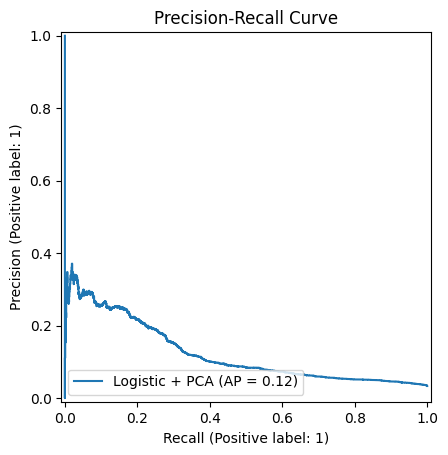

In [20]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_estimator(
    model_5,
    X_3_test_scaled,
    y_3_test,
    name="Logistic + PCA"
)

plt.title("Precision-Recall Curve")
plt.show()